In [5]:
#Salaheddine Ezzaarate
#AI was used for debugging and tidying .

!pip install python-dotenv
!pip install pandas
!pip install requests
!pip install seaborn

import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# get our api key
load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")
API_KEY = "7f0d8ef63f0cb38b60e1eee995f5dc994f08b57b"
url = f"https://api.census.gov/data/2024/acs/acs5/profile?get=NAME,DP03_0062E,DP02_0154PE,DP02_0152PE&for=county:*&in=state:37&key={API_KEY}"
response = requests.get(url)

data = response.json()
df = pd.DataFrame(data[1:], columns=data[0])

df = df.rename(columns={
    "DP03_0062E": "Median_Household_Income",
    "DP02_0154PE": "Pct_Broadband",
    "DP02_0152PE": "Pct_Computer"
})

print(df.shape)
print(df.isna().sum())

(100, 6)
NAME                       0
Median_Household_Income    0
Pct_Broadband              0
Pct_Computer               0
state                      0
county                     0
dtype: int64


In [7]:
target_cols = ["Median_Household_Income", "Pct_Broadband", "Pct_Computer"]
df[target_cols] = df[target_cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=target_cols)
print(df[["NAME", "Median_Household_Income", "Pct_Broadband", "Pct_Computer"]].head())
print(df.head())

                               NAME  Median_Household_Income  Pct_Broadband  \
0   Alamance County, North Carolina                    65651           90.2   
1  Alexander County, North Carolina                    65354           85.1   
2  Alleghany County, North Carolina                    47172           80.5   
3      Anson County, North Carolina                    47302           85.4   
4       Ashe County, North Carolina                    56866           85.2   

   Pct_Computer  
0         70062  
1         14126  
2          5177  
3          8548  
4         12201  
                               NAME  Median_Household_Income  Pct_Broadband  \
0   Alamance County, North Carolina                    65651           90.2   
1  Alexander County, North Carolina                    65354           85.1   
2  Alleghany County, North Carolina                    47172           80.5   
3      Anson County, North Carolina                    47302           85.4   
4       Ashe County, N

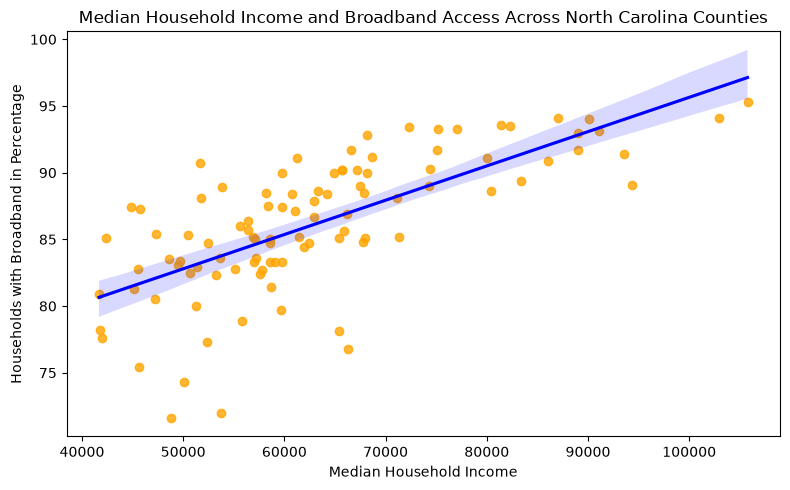

In [17]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Median_Household_Income", y="Pct_Broadband", scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
plt.title("Median Household Income and Broadband Access " "Across North Carolina Counties")
plt.xlabel("Median Household Income")
plt.ylabel("Households with Broadband in Percentage")
plt.tight_layout()
plt.show()

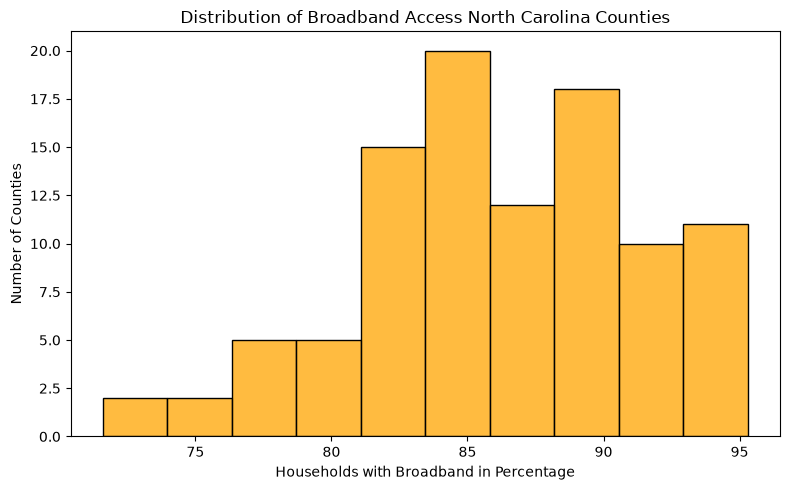

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Pct_Broadband", bins=10, color="orange")
plt.title("Distribution of Broadband Access " "North Carolina Counties")
plt.xlabel("Households with Broadband in Percentage")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()